In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Housing.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "harishkumardatalab/housing-price-prediction",
  file_path,
)


c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [4]:
# X-> features, y -> target
X=df.drop('price',axis=1)
y=df['price']

In [5]:
# numeric_features=["area","bedrooms","bathrooms","stories","parking"]
# categorical_features=["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea",
#                       "furnishingstatus"]
num_features=X.select_dtypes(include=['int64']).columns
cat_features=X.select_dtypes(include=['object']).columns


In [6]:
# dividing the data into taraining and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_test)

     area  bedrooms  bathrooms  stories mainroad guestroom basement  \
316  5900         4          2        2       no        no      yes   
77   6500         3          2        3      yes        no       no   
360  4040         2          1        1      yes        no       no   
90   5000         3          1        2      yes        no       no   
493  3960         3          1        1      yes        no       no   
..    ...       ...        ...      ...      ...       ...      ...   
15   6000         4          1        2      yes        no      yes   
357  6930         4          1        2       no        no       no   
39   6000         4          2        4      yes        no       no   
54   6000         3          2        2      yes       yes       no   
155  6100         3          2        1      yes        no      yes   

    hotwaterheating airconditioning  parking prefarea furnishingstatus  
316              no              no        1       no      unfurnished  
7

In [7]:
# encoding categorical features
from sklearn.preprocessing import OneHotEncoder,StandardScaler
encoder=OneHotEncoder(drop="first")
X_train_cat=encoder.fit_transform(X_train[cat_features]).toarray()
X_test_cat=encoder.transform(X_test[cat_features]).toarray()

print(X_train_cat)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]
 [1. 1. 0. ... 0. 1. 0.]]


In [8]:
# scaling numerical features
scaler=StandardScaler()
X_train_num=scaler.fit_transform(X_train[num_features])
X_test_num=scaler.transform(X_test[num_features])
print(X_train_num)

[[ 0.38416819  0.05527092  1.53917323  2.58764353  0.36795665]
 [ 0.9291807   0.05527092  1.53917323 -0.91249891  2.70998729]
 [-0.60775457 -1.28351359 -0.5579503  -0.91249891  1.53897197]
 ...
 [-0.29709744  0.05527092  1.53917323  1.42092939  0.36795665]
 [-0.5060189  -1.28351359 -0.5579503  -0.91249891 -0.80305867]
 [ 0.15707965  0.05527092  1.53917323  2.58764353  0.36795665]]


In [9]:
# combining numerical and categorical features
import numpy as np
X_train_final=np.hstack([X_train_num,X_train_cat])
X_test_final=np.hstack([X_test_num,X_test_cat])

# Training

In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_final,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Making Predictions

5668
436


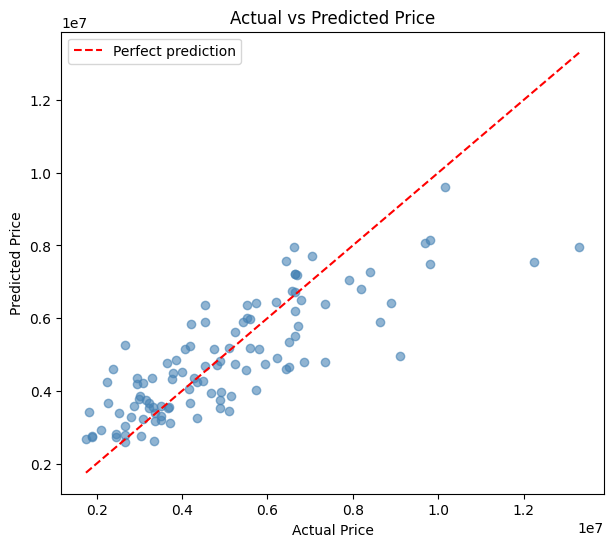

In [11]:
import matplotlib.pyplot as plt
y_pred=model.predict(X_test_final)
# print(y_pred)
print(X_train_final.size)
print(y_train.size)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.show()

# Model Evaluation

In [12]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print(f"MAE = {mae}")
print(f"RMSE = {rmse}")
print(f"R2 = {r2}")

MAE = 970043.4039201643
RMSE = 1324506.9600914405
R2 = 0.6529242642153175


In [13]:
import pandas as pd
new_house = pd.DataFrame({
    "area": [3000],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "mainroad": ["yes"],
    "guestroom": ["no"],
    "basement": ["yes"],
    "hotwaterheating": ["no"],
    "airconditioning": ["yes"],
    "parking": [2],
    "prefarea": ["yes"],
    "furnishingstatus": ["furnished"]
})
new_cat = encoder.transform(new_house[["mainroad","guestroom","basement","hotwaterheating","airconditioning",
                                      "prefarea","furnishingstatus"]]).toarray()
new_num = scaler.transform(new_house[["area","bedrooms","bathrooms","stories","parking"]])

new_final = np.hstack([new_num, new_cat])

predicted_price = model.predict(new_final)
print("Predicted Price:", predicted_price[0])

Predicted Price: 6831289.889876224
